## Conditioning

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# --- Variables de Configuración (Fase 1 y 2) ---
D_DRIFT_THRESHOLD = 50.0    # Umbral de Deriva (D)
T_THERMAL_THRESHOLD = 20.0  # Umbral de dispersión térmica (T)
ALPHA_LSO = 3.0             # Proporción de dispersión aceptada (alpha)

# --- Variables de Configuración (Fase 3: Rayos Cósmicos) ---
U_OUTLIER = 10            # Multiplicador del desvío (U)
K_COHERENCE = 3           # Ancho mínimo para señal real (K)
I_MAX_IMPACTS = 50        # Cantidad de impactos aceptados por muestra (I)

## Phase 1: Pre-processing of raw data

In [2]:
# raw_matrix es una matriz de 3694 x N, donde N es el número de espectros adquiridos
def fase_1_extraccion(raw_matrix):
    N = raw_matrix.shape[1]  # Número de espectros
    
    # 1. Verificación de rango (ADC 12 bits)
    if np.any(raw_matrix < 0) or np.any(raw_matrix > 4095):
        # En una implementación real, aquí dispararías el auto-reintento
        raise ValueError("Error de Integridad: Valores fuera de rango 0-4095 detectados.")

    # 2. Inversión de los datos (0 pasa a ser oscuro y 4095 pasa a ser brillante)
    data_inv = 4095 - raw_matrix

    # 3. Extracción de bloques:
    dummies_ini = data_inv[0:16, :]      # 16 píxeles (0 a 15)
    lso_bloque = data_inv[16:29, :]       # 13 píxeles (16 a 28)
    # Píxeles 29, 30 y 31 se saltan (descarte técnico)
    datos_efectivos = data_inv[32:3680, :] # 3648 píxeles (32 a 3679)
    dummies_fin = data_inv[3680:3694, :]   # 14 píxeles (3680 a 3693)

    return datos_efectivos, lso_bloque, dummies_ini, dummies_fin

## Phase 2: Treatment of ineffective blocks

In [ ]:
def fase_2_dummy_outputs(d_ini, d_fin, R, D=D_DRIFT_THRESHOLD, alpha_R=ALPHA_LSO):
    N = d_ini.shape[1]  # Número de espectros
    if d_fin.shape[1] != N:
        raise ValueError("Error: d_ini y d_fin deben tener el mismo número de espectros.")
    
    # 1. Métrica de deriva (Dummies)
    drift = np.abs(np.mean(d_ini, axis=0) - np.mean(d_fin, axis=0))
    if np.any(drift > D):
        print(f"(!) Alerta: Inestabilidad electrónica. Deriva detectada en {np.sum(drift > D)} espectros (drift máximo: {np.max(drift):.2f}).")

    # 2. Análisis de factibilidad
    sigma_d_ini = np.std(d_ini, axis=0)
    sigma_d_fin = np.std(d_fin, axis=0)
    if np.any(sigma_d_ini > (alpha_R * R)) or np.any(sigma_d_fin > (alpha_R * R)):
        print(f"(!) Alerta: Dummies inconsistentes (std_ini={np.max(sigma_d_ini):.2f}, std_fin={np.max(sigma_d_fin):.2f}).")

In [ ]:
def fase_2_shielded_outputs(datos_efectivos, lso_data, R, alpha_R=ALPHA_LSO, T=T_THERMAL_THRESHOLD):
    # Para cada muestra, calculo el promedio de los 13 pixeles
    lso_means = np.mean(lso_data, axis=0)

    # Metrica de dispersión interna: análisis de la consistencia dentro de cada bloque LSO
    lso_stds = np.std(lso_data, axis=0) # N valores de desviación estándar, uno por cada espectro
    if np.any(lso_stds > (alpha_R * R)):
        print(f"(!) Alerta: Bloque LSO inconsistente (std_max={np.max(lso_stds):.2f}).")

    # Metrica de consistencia temporal: no debería haber grandes variaciones entre una muestra y otra
    lso_means_sdt = np.std(lso_means)   # Calculo el desvío estandar del conjunto de promedios LSO a lo largo del tiempo (entre espectros)
    if lso_means_sdt > (T):
        print(f"(!) Alerta: Bloque LSO inconsistente en el tiempo (std={lso_means_sdt:.2f}).")

    datos_corregidos = datos_efectivos - lso_means[np.newaxis, :]
    datos_corregidos = np.clip(datos_corregidos, 0, None)  # Zero Clipping

    return datos_corregidos

# Testing

In [5]:
def generar_espectro_base(con_picos=True):
    x = np.arange(3648)
    # 1. Ruido de lectura (Read Noise)
    señal = np.random.normal(loc=20.0, scale=1.5, size=3648) 
    
    # 2. Picos Raman (Simulamos picos con ancho de ~4.5 px según Rasmussen)
    if con_picos:
        # Pico en pixel 1000 y 2500
        pico1 = 500 * np.exp(-((x - 1000)**2) / (2 * 2**2)) 
        pico2 = 300 * np.exp(-((x - 2500)**2) / (2 * 2**2))
        señal += pico1 + pico2
    
    return señal

def empaquetar_raw(datos_efectivos, offset_lso=3800, drift_final=0, ruido_lso=1.2):
    # Creamos el vector vacío de 3694
    raw = np.zeros(3694)
    
    # LSO (Shielded): Píxeles 16 a 28
    # El valor crudo es alto (oscuridad)
    raw[16:29] = np.random.normal(loc=offset_lso, scale=ruido_lso, size=13)
    
    # Dummies Iniciales: 0 a 15
    raw[0:16] = np.random.normal(loc=offset_lso, scale=2.0, size=16)
    
    # Datos Efectivos: 32 a 3679
    # Invertimos la señal: raw = 4095 - (señal + LSO_real)
    # Pero para testear tu resta de LSO, lo hacemos: raw = offset_lso - datos_efectivos
    raw[32:3680] = offset_lso - datos_efectivos
    
    # Dummies Finales: 3680 a 3693
    raw[3680:3694] = np.random.normal(loc=offset_lso + drift_final, scale=2.0, size=14)
    
    # Píxeles de transición (29 a 31) - Basura
    raw[29:32] = 2000 
    
    return np.clip(raw, 0, 4095)

In [6]:
muestras_ok = []
for _ in range(10):
    señal = generar_espectro_base()
    raw = empaquetar_raw(señal)
    muestras_ok.append(raw)

matriz_ok = np.array(muestras_ok).T # Matriz de 3694 x 10
print("Matriz OK generada:", matriz_ok.shape)

muestras_error = []
for i in range(10):
    señal = generar_espectro_base()
    
    if i == 0: # Caso 1: Deriva electrónica (Dummy final muy distinto al inicial)
        raw = empaquetar_raw(señal, drift_final=200)
    elif i == 1: # Caso 2: Bloque LSO muy ruidoso (Inestabilidad de lectura)
        raw = empaquetar_raw(señal, ruido_lso=50.0)
    elif i == 2: # Caso 3: Salto térmico (LSO promedio cambia mucho)
        raw = empaquetar_raw(señal, offset_lso=3200)
    else: # Los demás están bien
        raw = empaquetar_raw(señal)
        
    muestras_error.append(raw)

matriz_error = np.array(muestras_error).T
print("Matriz Error generada:", matriz_error.shape)

Matriz OK generada: (3694, 10)
Matriz Error generada: (3694, 10)


--- PROCESANDO SET DE DATOS CORRECTOS ---
Resultado Set OK: Matriz final de (3648, 10)

----------------------------------------

--- PROCESANDO SET DE DATOS CON FALLAS ---
⚠️ Alerta: Inestabilidad electrónica. Deriva detectada en 1 espectros (drift máximo: 199.96).
⚠️ Alerta: Bloque LSO inconsistente (std_max=50.42).
⚠️ Alerta: Bloque LSO inconsistente en el tiempo (std=179.82).


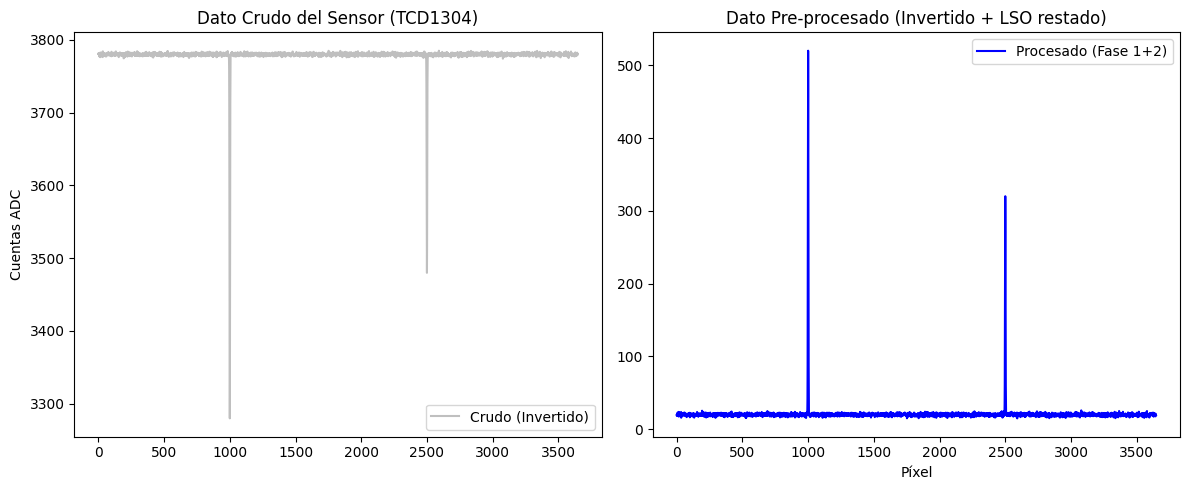

In [ ]:
# --- 1. Inicialización de la Calibración ---
# Supongamos que ya corriste la calibración y tenés estos valores:
R_SISTEMA = 1.2    # Ruido de lectura base
ALPHA = 3.0        # Factor de tolerancia (alpha_R)
T_SESION = 15.0    # Umbral de estabilidad térmica (T)
D_LIMITE = 50.0    # Umbral de deriva electrónica (D)

# --- 2. Procesamiento del Conjunto "OK" ---
print("--- PROCESANDO SET DE DATOS CORRECTOS ---")
# Fase 1: Extracción
datos_ok, lso_ok, dini_ok, dfin_ok = fase_1_extraccion(matriz_ok)

# Fase 2: Validación de Hardware (Dummies)
fase_2_dummy_outputs(dini_ok, dfin_ok, D_LIMITE, R_SISTEMA, ALPHA)

# Fase 2: Limpieza Térmica (Shielded)
espectros_limpios_ok = fase_2_shielded_outputs(datos_ok, lso_ok, ALPHA, R_SISTEMA, T_SESION)
print(f"Resultado Set OK: Matriz final de {espectros_limpios_ok.shape}")

print("\n" + "-"*40 + "\n")

# --- 3. Procesamiento del Conjunto "ERROR" ---
print("--- PROCESANDO SET DE DATOS CON FALLAS ---")
try:
    # Fase 1: Extracción
    datos_err, lso_err, dini_err, dfin_err = fase_1_extraccion(matriz_error)
    
    # Fase 2: Validación de Hardware (Dummies)
    # Debería saltar la alerta de deriva en el espectro 0
    fase_2_dummy_outputs(dini_err, dfin_err, D_LIMITE, R_SISTEMA, ALPHA)
    
    # Fase 2: Limpieza Térmica (Shielded)
    # Debería saltar alerta de LSO ruidoso (espectro 1) e inestabilidad temporal (espectro 2)
    espectros_limpios_err = fase_2_shielded_outputs(datos_err, lso_err, ALPHA, R_SISTEMA, T_SESION)
    
except ValueError as e:
    print(f"(!) Error de integridad: {e}")

# --- 4. Visualización de Resultados ---
plt.figure(figsize=(12, 5))

# Graficamos el primer espectro del set OK (antes y después)
plt.subplot(1, 2, 1)
plt.plot(matriz_ok[32:3680, 0], label='Crudo (Invertido)', color='gray', alpha=0.5)
plt.title("Dato Crudo del Sensor (TCD1304)")
plt.ylabel("Cuentas ADC")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(espectros_limpios_ok[:, 0], label='Procesado (Fase 1+2)', color='blue')
plt.title("Dato Pre-procesado (Invertido + LSO restado)")
plt.xlabel("Píxel")
plt.legend()

plt.tight_layout()
plt.show()

# Cosmic Rays Detection

In [11]:
def fase_3_rayos_cosmicos(matriz_n, R_base, alpha_R, Ua, Ud, K, I_limite):
    """
    matriz_n: matriz de (3648, N) ya con LSO restado y Zero Clipping.
    R_base: el ruido de lectura guardado de alguna calibración.
    Ua:  factor multiplicador del desvío estándar para identificar un píxel con posible anomalía.
    Ud: multiplicador del promedio del detector
    K: número mínimos de píxeles contiguos para considerar un evento como “señal real”
    I_limite: max impactos por muestra.
    """
    total_px, N = matriz_n.shape
    matriz_limpia = matriz_n.astype(float).copy()
    
    # --- Paso 1: Análisis de dispersión temporal ---
    # Identificar en qué píxeles ocurre una variabilidad anormalmente alta a lo largo de las N muestras
    sigmas_i = np.std(matriz_n, axis=1) # Desvío estándar de cada píxel en el tiempo
    medianas_i = np.median(matriz_n, axis=1)
    promedio_detector = np.mean(sigmas_i)
    
    # Identificación de píxeles sospechosos (Desvío > promedio del detector)
    # Usamos un multiplicador (ej. 2.0) para definir qué es "anormalmente alto"
    sospechosos = np.where(sigmas_i > (Ud * promedio_detector))[0]
    
    impactos_por_muestra = np.zeros(N)
    pixeles_afectados_coords = [] # Para las métricas finales

    # --- Paso 2 e Identificación ---
    for i in sospechosos:
        for j in range(N):
            # Test de Outlier:
            distancia = matriz_n[i, j] - medianas_i[i]
            
            if distancia > (Ua * sigmas_i[i]):
                # --- Paso 3: Test de coherencia de vecinos (Espacial) ---
                # Miramos un entorno de +/- K píxeles en esa misma muestra j
                entorno = matriz_n[max(0, i-K):min(total_px, i+K), j]
                # Contamos cuántos vecinos también saltaron
                # (un salto se considera > mediana + ruido base)
                umbral_ruido = medianas_i[max(0, i-K):min(total_px, i+K)] + alpha_R * R_base
                puntos_altos = np.sum(entorno > umbral_ruido)
                
                # Veredicto por Ancho de Banda
                if puntos_altos <= K:
                    # ES RAYO CÓSMICO
                    pixeles_afectados_coords.append((i, j))
                    impactos_por_muestra[j] += 1
                # Si puntos_altos > K, se asume señal real (pico Raman) y no se hace nada

    # --- Paso 4: Reconstrucción ---
    for i, j in pixeles_afectados_coords:
        # Si la muestra j no fue descartada por superar el límite I
        if impactos_por_muestra[j] <= I_limite:
            # Reemplazo por el promedio de las demás muestras sanas de ese píxel
            valores_sanos = np.delete(matriz_n[i, :], j)
            matriz_limpia[i, j] = np.mean(valores_sanos)
            
    # --- Paso 5: Registro de Métricas ---
    # Métrica (b)
    p_procesamiento = (len(pixeles_afectados_coords) / (total_px * N)) * 100
    
    # Muestras descartadas
    muestras_validas = np.where(impactos_por_muestra <= I_limite)[0]
    
    return matriz_limpia[:, muestras_validas], p_procesamiento, impactos_por_muestra

# Test

Métricas del procesamiento:
- Porcentaje de píxeles corregidos: 0.0000%
- Impactos detectados por muestra: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
- Muestras finales restantes: 10 de 10


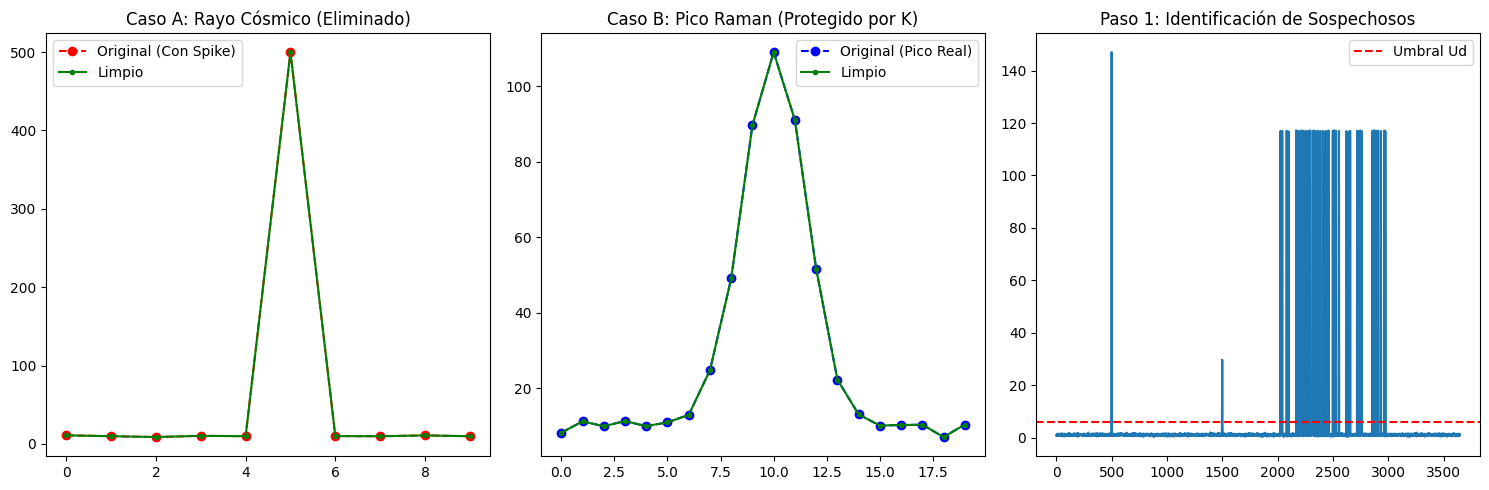

In [13]:
# --- 1. Generación de Datos de Prueba ---
N_muestras = 10
puntos = 3648
R_base_test = 1.2
alpha_R_test = 3.0

# Creamos una matriz con ruido base (sesión estable)
np.random.seed(42) # Para que siempre te de igual el test
matriz_test = np.random.normal(loc=10.0, scale=R_base_test, size=(puntos, N_muestras))

# CASO A: Un Rayo Cósmico real (píxel 500, muestra 2)
# Es un solo píxel que vuela muy alto.
matriz_test[500, 2] = 500.0 

# CASO B: Un pico Raman real que apareció (píxel 1500, muestra 4)
# Es un pico ancho (~5 píxeles). Ud y Ua lo marcarán como outlier, 
# pero el test K debería salvarlo.
x_pico = np.arange(1490, 1510)
pico_real = 100.0 * np.exp(-((x_pico - 1500)**2) / (2 * 1.5**2))
matriz_test[1490:1510, 4] += pico_real

# CASO C: Una muestra "maldita" con demasiados impactos (muestra 8)
# Superamos I_limite para ver si descarta la muestra entera.
indices_ruido = np.random.randint(2000, 3000, 60) # 60 impactos
matriz_test[indices_ruido, 8] = 400.0

# --- 2. Ejecución de tu Función ---
# Parámetros sugeridos por tus definiciones:
# Ud = 2.0 (detecta si el píxel varía más que el doble del promedio)
# Ua = 5.0 (detecta si el salto es 5 sigmas respecto a su propia historia)
# K = 3   (Rasmussen: picos de <3 px son ruido)
# I_limite = 50 (máximo impactos permitidos)

matriz_limpia, p_proc, impactos = fase_3_rayos_cosmicos(
    matriz_test, 
    R_base=R_base_test, 
    alpha_R=2, 
    Ua=5.0, Ud=2.0, K=3, 
    I_limite=50
)

# --- 3. Verificación de Resultados ---
print(f"Métricas del procesamiento:")
print(f"- Porcentaje de píxeles corregidos: {p_proc:.4f}%")
print(f"- Impactos detectados por muestra: {impactos}")
print(f"- Muestras finales restantes: {matriz_limpia.shape[1]} de {N_muestras}")

# --- 4. Visualización ---
plt.figure(figsize=(15, 5))

# Gráfico 1: El Rayo Cósmico eliminado
plt.subplot(1, 3, 1)
plt.plot(matriz_test[495:505, 2], 'ro--', label='Original (Con Spike)')
plt.plot(matriz_limpia[495:505, 2], 'g.-', label='Limpio')
plt.title("Caso A: Rayo Cósmico (Eliminado)")
plt.legend()

# Gráfico 2: El pico Raman salvado por Coherencia K
plt.subplot(1, 3, 2)
plt.plot(matriz_test[1490:1510, 4], 'bo--', label='Original (Pico Real)')
plt.plot(matriz_limpia[1490:1510, 4], 'g.-', label='Limpio')
plt.title("Caso B: Pico Raman (Protegido por K)")
plt.legend()

# Gráfico 3: La varianza temporal (Paso 1 de tu lógica)
plt.subplot(1, 3, 3)
sigmas = np.std(matriz_test, axis=1)
plt.plot(sigmas)
plt.axhline(y=np.mean(sigmas)*2.0, color='r', linestyle='--', label='Umbral Ud')
plt.title("Paso 1: Identificación de Sospechosos")
plt.legend()

plt.tight_layout()
plt.show()